In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('26-customer_data.csv')
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


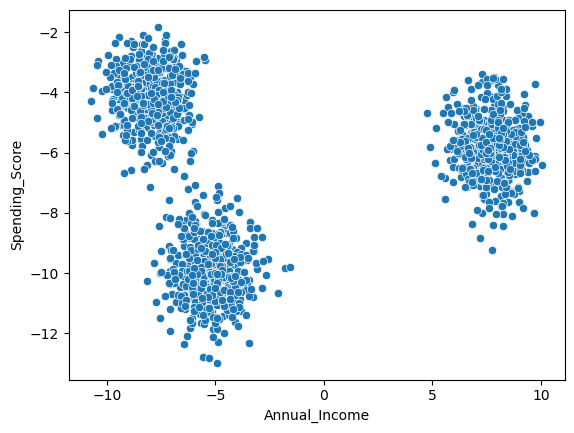

In [5]:
sns.scatterplot(data = df , x = 'Annual_Income' , y = 'Spending_Score')
plt.show()

In [6]:
# Bu datasette elimizde bir y yani tahmin edilecek bir kolon yok. Sadece kümeleme yapacağız.

In [7]:
from sklearn.model_selection import train_test_split

X_train , X_test = train_test_split(df , test_size = 0.2 , random_state = 15 )


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1 , 11) :
    kmeans = KMeans(n_clusters = i , init = 'k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

  File "C:\Users\MSI-NB\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\MSI-NB\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MSI-NB\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MSI-NB\anaconda3\Lib\subproc

In [10]:
wcss

[196.92068784710153,
 68.44836482219306,
 11.697030239519936,
 11.081183656922509,
 7.88271495991101,
 6.089330072204833,
 5.503400431805147,
 5.045894231459245,
 4.684758421202617,
 4.13879768672394]

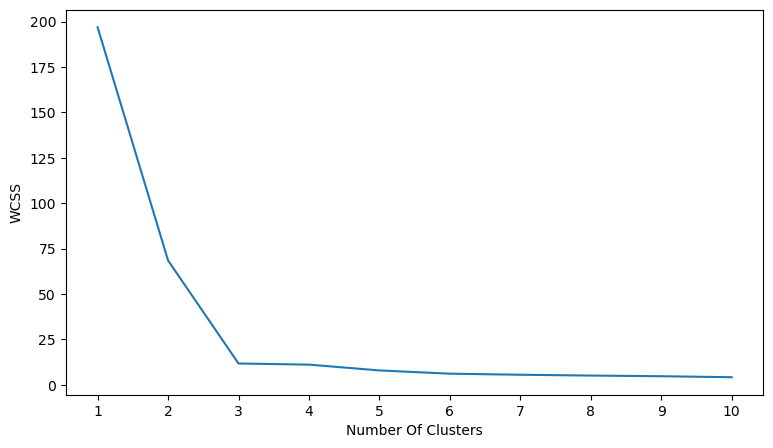

In [11]:
plt.figure(figsize = (9 , 5))
plt.plot(range(1 , 11) , wcss)
plt.xticks(range(1 , 11))
plt.xlabel('Number Of Clusters')
plt.ylabel('WCSS')
plt.show()

# KIRILIM NET ŞEKİLDE GÖRUNUYOR EN UYGUN CLUSTER(KUME) SAYISI 3 İMİŞ

In [12]:
kmeans = KMeans(n_clusters = 3 , init = 'k-means++')
kmeans.fit(X_train_scaled)

KMeans(n_clusters=3)

In [13]:
X_test_df = pd.DataFrame(data = X_test_scaled , columns = X_test.columns)
y_pred = kmeans.predict(X_test_df)

In [14]:
y_pred # 3 sınıfa ayırmış ve elindeki verilerin sınıflarını yazmış

array([2, 0, 0, 1, 2, 0, 1, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 1, 1, 1, 0, 0,
       2, 2, 1, 2, 2, 2, 0, 0, 2, 0, 0, 0, 2, 1, 0, 2, 0, 2, 1, 0, 1, 1,
       0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1, 0, 2, 0, 2, 1, 0, 2, 1, 0, 1, 1,
       1, 0, 1, 2, 0, 2, 0, 2, 2, 1, 2, 2, 2, 1, 0, 0, 1, 2, 1, 0, 1, 1,
       0, 2, 1, 0, 0, 1, 0, 2, 2, 1, 0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 2, 2,
       0, 2, 2, 0, 1, 0, 2, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 2, 1, 0, 2, 2,
       2, 2, 1, 2, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 2, 0, 2, 0, 0, 2, 2, 2, 0, 1, 2, 0, 2, 0, 0, 0, 2, 2, 1, 0, 0,
       1, 2, 2, 1, 2, 1, 0, 2, 2, 1, 1, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 2,
       2, 0, 0, 1, 2, 1, 2, 1, 0, 0, 2, 2, 1, 2, 0, 1, 2, 0, 2, 1, 0, 1,
       1, 2, 2, 0, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 0, 1, 2, 1, 0, 0, 0, 1,
       0, 1, 2, 1, 1, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 0, 2, 0, 0, 2,
       1, 1, 0, 2, 2, 1, 2, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 2, 1, 0, 0,
       2, 1, 2, 0, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1], d

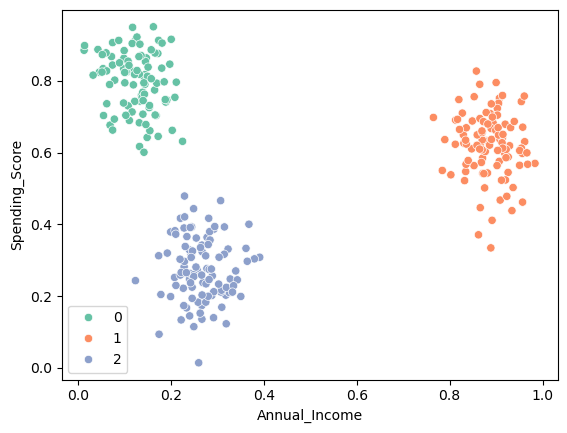

In [15]:
sns.scatterplot(data = X_test_df , x = 'Annual_Income' , y = 'Spending_Score' , hue = y_pred , palette ="Set2")
plt.show()

In [16]:
# Ideal küme sayısını bulmaya yarayan basti bir yol : 
!pip install kneed

In [17]:
from kneed import KneeLocator

kl = KneeLocator(range(1 , 11 ) , wcss , curve = 'convex' , direction = 'decreasing')

kl.elbow # İdeal kümeleme yani kmeans = KMeans(n_clusters = 3) imiş

np.int64(3)

In [18]:
# Farkı bir elbow bulma metodu

# Silhoutte score'un en fazla olduğu yer bu datasetin kümelenmesi uygun olan küme sayısıdır

In [19]:
from sklearn.metrics import silhouette_score

silhoutte = []

for k in range(1,11) : 
    kmeans = KMeans(n_clusters = k + 1 , init = 'k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled , kmeans.labels_ )
    silhoutte.append(score)

In [20]:
silhoutte

[np.float64(0.4808525318845209),
 np.float64(0.7856941696336582),
 np.float64(0.6400208011797931),
 np.float64(0.5102875996193406),
 np.float64(0.49824345548799676),
 np.float64(0.38200071658298507),
 np.float64(0.3584360274260232),
 np.float64(0.3660856439775809),
 np.float64(0.3405476936268203),
 np.float64(0.3454998556210368)]

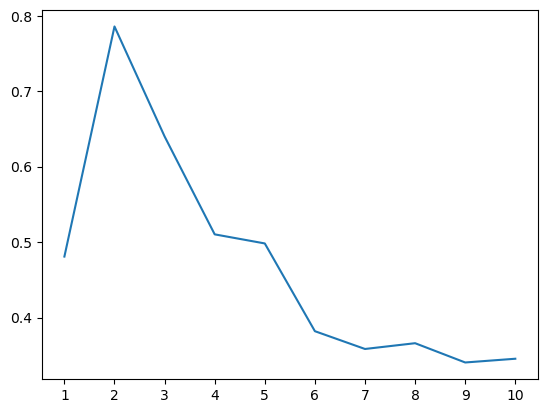

In [21]:
plt.plot(range (1,11) , silhoutte)
plt.xticks(range(1 , 11))
plt.show()